In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import pickle
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
#

dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l'])
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l'])
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l'])
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l'])


/var/folders/ll/kxnszbbj3b1bqwnlk_bqpjl8ffbpq7/T/ipykernel_58277/2656010543.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=18)
/var/folders/ll/kxnszbbj3b1bqwnlk_bqpjl8ffbpq7/T/ipykernel_58277/2656010543.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=18)
/var/folders/ll/kxnszbbj3b1bqwnlk_bqpjl8ffbpq7/T/ipykernel_58277/2656010543.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=18)
/var/folders/ll/kxnszbbj3b1bqwnlk_bqpjl8ffbpq7/T/ipykernel_58277/2656010543.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usin

[0.00000000e+00 2.02941365e-16 6.08824095e-16 4.05882730e-16
 4.05882730e-16 4.05882730e-16 4.05882730e-16 2.02941365e-16
 1.21764819e-15 4.05882730e-15 0.00000000e+00 3.24706184e-15]
[9.91685105e-16 1.38835921e-15] [Array(0.8997065, dtype=float32), Array(1., dtype=float32)]


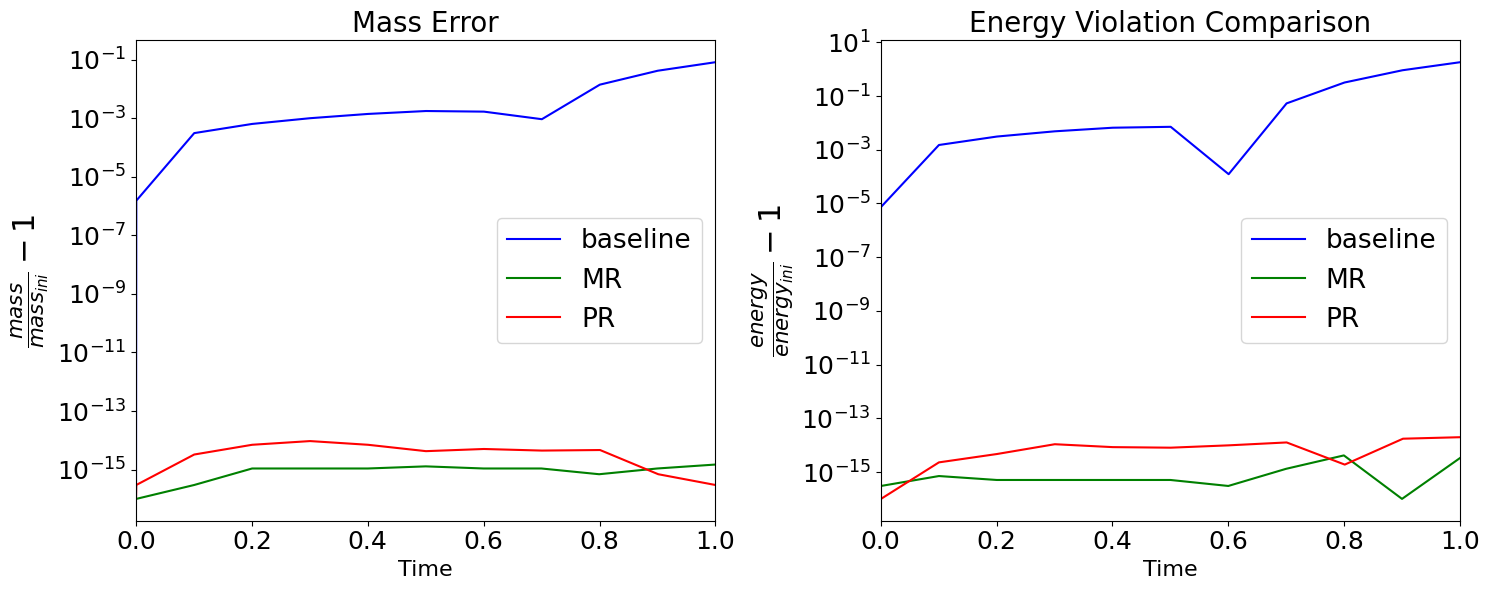

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

########################
fold_list = ["./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/","./_data_twoGauss_multiRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/",\
             "./_data_twoGauss_projRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/","./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_1e-05/"]
folder = fold_list[0]
with open(folder+"case_dict.pkl", 'rb') as file:
    data = pickle.load(file)
    print(data.keys())

folder_multi_relax = fold_list[1]
with open(folder_multi_relax+"case_dict.pkl", 'rb') as file:
    data_multi_relax = pickle.load(file)
    print(data_multi_relax.keys())

folder_proj_relax = fold_list[2]
with open(folder_proj_relax+"case_dict.pkl", 'rb') as file:
    data_proj_relax = pickle.load(file)
    print(data_proj_relax.keys())

folder_small_dt = fold_list[3]
with open(folder_small_dt+"case_dict.pkl", 'rb') as file:
    data_small_dt = pickle.load(file)
    print(data_small_dt.keys())

#######################

mass_err_l = np.abs(np.array(data['mass_err_l']))
energy_violation = np.abs(np.array(data['energy_err_l']))
mass_err_l_multi_relax = np.abs(np.array(data_multi_relax['mass_err_l']))
energy_violation_multi_relax = np.abs(np.array(data_multi_relax['energy_err_l']))
mass_err_l_proj_relax = np.abs(np.array(data_proj_relax['mass_err_l']))
energy_violation_proj_relax = np.abs(np.array(data_proj_relax['energy_err_l']))
mass_err_l_small_dt = np.abs(np.array(data_small_dt['mass_err_l']))
energy_violation_small_dt = np.abs(np.array(data_small_dt['energy_err_l']))

# Create a GridSpec with 2 rows and 2 columns
fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(1, 2, figure=fig)


# Mass Error Comparison (span the entire first row)
ax1 = fig.add_subplot(gs[0, 0])  
ax1.plot(data['t_list'][:], mass_err_l+1e-16,color="blue",label="baseline")#'Mass Error')
ax1.plot(data_multi_relax['t_list'][:], mass_err_l_multi_relax+1e-16,color="green", label="MR")#'Mass Error Relaxed')
ax1.plot(data_proj_relax['t_list'][:], mass_err_l_proj_relax+1e-16,color="red", label="PR")#'Mass Error Relaxed')
#ax1.plot(data_small_dt['t_list'][:], mass_err_l_small_dt+1e-16,color="orange", label="small dt")#'Mass Error Relaxed')
ax1.set_yscale('log')
ax1.set_xlabel('Time',fontsize=16)
ax1.set_ylabel(r'$\frac{mass}{mass_{ini}}-1$', fontsize=22)
ax1.set_xlim([0.0,1.0])
ax1.legend(loc="best",fontsize=19)
ax1.set_title('Mass Error', fontsize=20)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=18)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=18)

# Energy Violation Comparison (bottom-left subplot)
ax2 = fig.add_subplot(gs[0, 1])  
ax2.plot(data['t_list'][:], energy_violation+1e-16,color="blue", label='baseline')
ax2.plot(data_multi_relax['t_list'][:], energy_violation_multi_relax+1e-16,color="green", label='MR')
ax2.plot(data_proj_relax['t_list'][:], energy_violation_proj_relax+1e-16,color="red", label='PR')
#ax2.plot(data_small_dt['t_list'][:], energy_violation_small_dt+1e-16,color="orange", label="small dt")
ax2.set_yscale('log')
ax2.set_xlabel('Time',fontsize=16)
ax2.set_ylabel(r'$\frac{energy}{energy_{ini}}-1$', fontsize=22)
ax2.set_xlim([0.0,1.0])
ax2.legend(loc="best",fontsize=19)
ax2.set_title('Energy Violation Comparison', fontsize=20)
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=18)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=18)




plt.tight_layout()
#plt.show()
#plt.savefig("two_gauss_mass_energy.pdf",dpi=300,bbox_inches='tight')
plt.savefig("./_figures_two_gauss/two_gauss_mass_energy_p0005.pdf",dpi=300,bbox_inches='tight')
print(energy_violation_multi_relax)
print(mass_err_l_multi_relax[-2:],data_multi_relax["t_list"][-2:])



dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
[Array(0., dtype=float64), Array(0.99951172, dtype=float64), Array(0., dtype=float64), Array(0.99951172, dtype=float64)]
[0.0, 0.99951171875, 0.0, 0.99951171875]
[0.0, 0.99951171875, 0.0, 0.99951171875]
Ass [0.5] [768, 1280] [896, 1152]
[1.0] [1.0] [1.0]
./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/frame_1.0.npz
./_data_twoGauss_multiRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/frame_1.0.npz
---- complex128
./_data_twoGauss_projRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/frame_1.0.npz
Max difference 210026.77375018125
Max difference proj relax 176934.39010965417


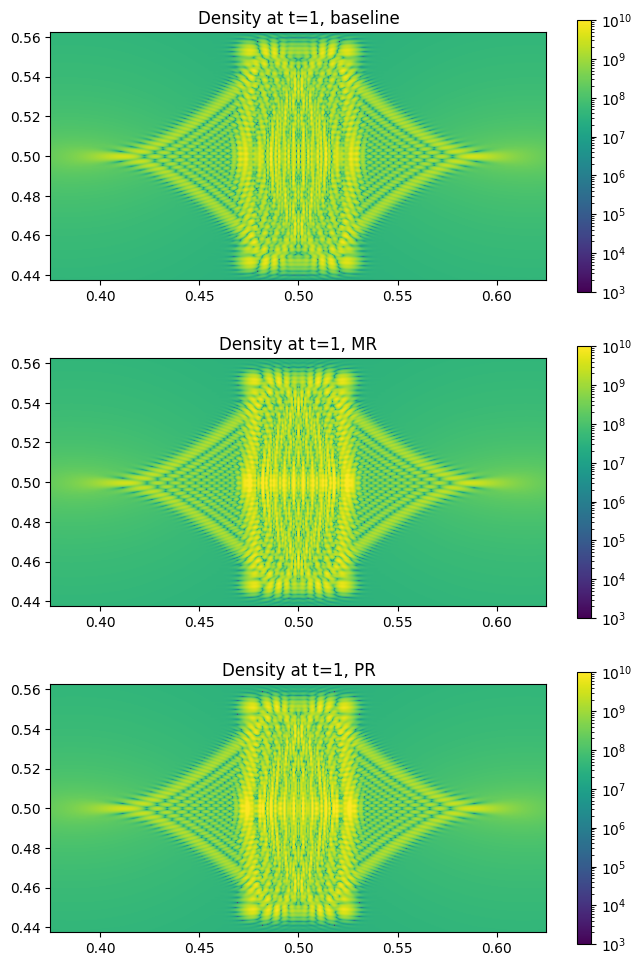

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import matplotlib.colors as colors
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
fold_list = ["./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/","./_data_twoGauss_multiRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/","./_data_twoGauss_projRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/"]
#fold_list = ["./_data/imex_ARK3(2)4L[2]SA_1024_1e-05_zero_vel/","./_data/imex_ARK3(2)4L[2]SA_1024_1e-05_zero_vel_relaxed_massOnly/"]
#fold_list = ["./_data/imex_ARK3(2)4L[2]SA_" + str(m) + "_5e-05_zero_vel_relaxedTest/","./_data/imex_ARK3(2)4L[2]SA_" + str(m_r) + "_5e-05_zero_vel_relaxedTest/"]
folder = fold_list[0]
folder_relax = fold_list[1]
folder_proj_relax = fold_list[2]
#folder_mass_relax = fold_list[2]
folder_case = folder + "case_dict.pkl"
folder_relax_case = folder_relax + "case_dict.pkl"
folder_proj_relax_case = folder_proj_relax + "case_dict.pkl"
# folder_mass_relax_case = folder_mass_relax + "case_dict.pkl"
with open(folder_case, 'rb') as file:
    data = pickle.load(file)
    m = data["frame_list"][0].shape
    print(data.keys(),m)
    
with open(folder_relax_case, 'rb') as file:
    data_relax = pickle.load(file)
    m_r = data_relax["frame_list"][0].shape
    print(data_relax.keys(),m_r)

with open(folder_proj_relax_case, 'rb') as file:
    data_proj_relax = pickle.load(file)
    m_pr = data_proj_relax["frame_list"][0].shape
    print(data_proj_relax.keys(),m_pr)

# with open(folder_mass_relax_case, 'rb') as file:
#     data_mass_relax = pickle.load(file)
#     m_mass = data_mass_relax["frame_list"][0].shape
   


i_list = [1.0]#list(range(0,len(data['t_list'])-1))
i_list_relax =[1.0]
i_list_proj_relax =[1.0]#list(range(0,len(data_relax['t_list'])-1))
t_list = data['t_list']
t_list_relax = data_relax['t_list']
t_list_proj_relax = data_proj_relax['t_list']

xlist = data["X"]
x = xlist[0]
y = xlist[1]

xlist = data_relax["X"]
x_r = np.array(xlist[0])
y_r = np.array(xlist[1])

xlist = data_proj_relax["X"]
x_pr = np.array(xlist[0])
y_pr = np.array(xlist[1])
print([y.min(), y.max(), x.min(), x.max()])
print([y_r.min(), y_r.max(), x_r.min(), x_r.max()])
print([y_pr.min(), y_pr.max(), x_pr.min(), x_pr.max()])
# xlist = data_mass_relax["x"]
# x_r_m = xlist[0]
# y_r_m = xlist[1]

file_n = folder+"frame_"
file_n_relax = folder_relax+"frame_"
file_n_proj_relax = folder_proj_relax+"frame_"
# file_n_mass_relax = folder_mass_relax+"frame_"



xlim = [3.0/8.0,5.0/8.0]
ylim = [7.0/16.0,9./16.0]
xlim_ind = [int((xlim[0]-x.min())/(x.max()-x.min())*m[0]),int((xlim[1]-x.min())/(x.max()-x.min())*m[0])]
ylim_ind = [int((ylim[0]-y.min())/(y.max()-y.min())*m[1]),int((ylim[1]-y.min())/(y.max()-y.min())*m[1])]
asp = np.diff(ylim)/np.diff(xlim)
print("Ass",asp,xlim_ind,ylim_ind)


fig = plt.figure(figsize=(8*len(i_list), 12))
gs = gridspec.GridSpec(3, len(i_list), figure=fig)
#plt.xlim([-xlim,xlim])
#plt.ylim([-xlim,xlim])

print(i_list,i_list_relax,i_list_proj_relax)
for i1,i2,i3 in zip(i_list,i_list_relax,i_list_proj_relax):

    ax = fig.add_subplot(gs[0, i_list.index(i1)])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    frame = np.load(file_n + str(i1) + ".npz")['frame']
    print(file_n + str(i1) + ".npz")
    mass = np.mean(np.square(np.abs(frame)))
    
    frame_relax = np.array(np.load(file_n_relax + str(i2) + ".npz")['frame'])
    print(file_n_relax + str(i2) + ".npz")
    mass_relax = np.mean(np.square(np.abs(frame_relax)))

    frame_proj_relax = np.array(np.load(file_n_proj_relax + str(i3) + ".npz")['frame'])
    print("----",frame_proj_relax.dtype)
    print(file_n_proj_relax + str(i3) + ".npz")
    mass_proj_relax = np.mean(np.square(np.abs(frame_proj_relax)))
    #print(frame.shape,i_list_relax.index(i2),mass,mass_relax)

    #print("Diff",np.max(np.abs(frame-frame_relax)))
    
    #frame_mass_relax = np.load(file_n_mass_relax + str(i2) + ".npz")['frame']

    Z = np.square(np.abs(frame))
    #pclm = ax.pcolormesh(y,x,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax.imshow(Z,extent=[y.min(), y.max(), x.min(), x.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
      
    fig.colorbar(pclm,ax=ax)
    ax.set_title("Density at t=1, baseline")
    ax.set_box_aspect(asp)
    #fig.colorbar(ax.imshow(np.abs(frame)**2), ax=ax)

    ax2 = fig.add_subplot(gs[1, i_list_relax.index(i2)])
    ax2.set_box_aspect(asp)
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    Z = np.square(np.abs(frame_relax))
    print("Max difference",np.abs(frame-frame_relax).max())
    #pclm = ax2.pcolormesh(y_r,x_r,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax2.imshow(Z,extent=[y_r.min(), y_r.max(), x_r.min(), x_r.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
      
    fig.colorbar(pclm,ax=ax2)
    ax2.set_title("Density at t=1, MR")


    ax3 = fig.add_subplot(gs[2, i_list_proj_relax.index(i3)])
    ax3.set_box_aspect(asp)
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    Z = np.square(np.abs(frame_proj_relax))
    print("Max difference proj relax",np.abs(frame-frame_proj_relax).max())
    #pclm = ax2.pcolormesh(y_r,x_r,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax3.imshow(Z,extent=[y_pr.min(), y_pr.max(), x_pr.min(), x_pr.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
      
    fig.colorbar(pclm,ax=ax3)
    ax3.set_title("Density at t=1, PR")




    # ax2 = fig.add_subplot(gs[2, i_list.index(i1)])
    # #ax2.set_xlim([-xlim,xlim])
    # Z = np.abs(np.square(np.abs(frame))-np.square(np.abs(frame_relax)))
    # Z = np.square(np.abs(frame_mass_relax))
    # pclm = ax2.pcolormesh(y_r_m,x_r_m,Z,norm=LogNorm(vmin=Z.min()+1e-14, vmax=Z.max()))
      
    #fig.colorbar(pclm,ax=ax2)
    #ax2.set_title("t = "+str(round(t_list_relax[i+1],2))+", mass = "+str(round(mass_relax,5)))
    #fig.colorbar(ax2.imshow(np.abs(frame_relax)**2), ax=ax2)
    #plt.pause(0.1)
#plt.tight_layout()
plt.savefig("./_figures_two_gauss/two_gauss_density_comparison_dt0p0005.pdf",dpi=300,bbox_inches='tight')



dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
[Array(0., dtype=float64), Array(0.99951172, dtype=float64), Array(0., dtype=float64), Array(0.99951172, dtype=float64)]
[0.0, 0.99951171875, 0.0, 0.99951171875]
[0.0, 0.99951171875, 0.0, 0.99951171875]
Ass [0.5] [768, 1280] [896, 1152]
[1.0] [1.0] [1.0] [1.0]
./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.001/frame_1.0.npz
./_data_twoGauss_multiRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.001/frame_1.0.npz
---- complex128
./_data_twoGauss_projRlx

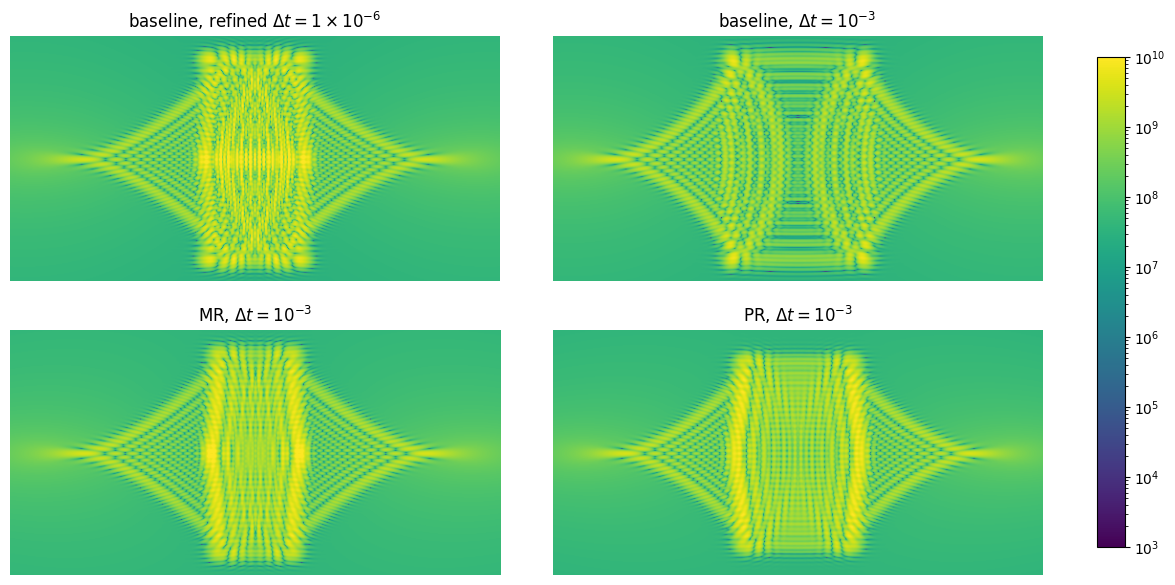

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import matplotlib.colors as colors
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
fold_list = ["./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.001/","./_data_twoGauss_multiRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.001/",\
             "./_data_twoGauss_projRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.001/","./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_1e-06/"]
#fold_list = ["./_data/imex_ARK3(2)4L[2]SA_1024_1e-05_zero_vel/","./_data/imex_ARK3(2)4L[2]SA_1024_1e-05_zero_vel_relaxed_massOnly/"]
#fold_list = ["./_data/imex_ARK3(2)4L[2]SA_" + str(m) + "_5e-05_zero_vel_relaxedTest/","./_data/imex_ARK3(2)4L[2]SA_" + str(m_r) + "_5e-05_zero_vel_relaxedTest/"]
folder = fold_list[0]
folder_relax = fold_list[1]
folder_proj_relax = fold_list[2]
folder_refined = fold_list[3]
#folder_mass_relax = fold_list[2]
folder_case = folder + "case_dict.pkl"
folder_relax_case = folder_relax + "case_dict.pkl"
folder_proj_relax_case = folder_proj_relax + "case_dict.pkl"
folder_refined_case = folder_refined + "case_dict.pkl"
# folder_mass_relax_case = folder_mass_relax + "case_dict.pkl"
with open(folder_case, 'rb') as file:
    data = pickle.load(file)
    m = data["frame_list"][0].shape
    print(data.keys(),m)
    
with open(folder_relax_case, 'rb') as file:
    data_relax = pickle.load(file)
    m_r = data_relax["frame_list"][0].shape
    print(data_relax.keys(),m_r)

with open(folder_proj_relax_case, 'rb') as file:
    data_proj_relax = pickle.load(file)
    m_pr = data_proj_relax["frame_list"][0].shape
    print(data_proj_relax.keys(),m_pr)

with open(folder_refined_case, 'rb') as file:
    data_refined = pickle.load(file)
    m_ref = data_refined["frame_list"][0].shape
    print(data_refined.keys(),m_ref)

# with open(folder_mass_relax_case, 'rb') as file:
#     data_mass_relax = pickle.load(file)
#     m_mass = data_mass_relax["frame_list"][0].shape
   


i_list = [1.0]#list(range(0,len(data['t_list'])-1))
i_list_relax =[1.0]
i_list_proj_relax =[1.0]#list(range(0,len(data_relax['t_list'])-1))
i_list_refined =[1.0]
t_list = data['t_list']
t_list_relax = data_relax['t_list']
t_list_proj_relax = data_proj_relax['t_list']
t_list_refined = data_refined['t_list']

xlist = data["X"]
x = xlist[0]
y = xlist[1]

xlist = data_relax["X"]
x_r = np.array(xlist[0])
y_r = np.array(xlist[1])

xlist = data_proj_relax["X"]
x_pr = np.array(xlist[0])
y_pr = np.array(xlist[1])

xlist = data_refined["X"]
x_ref = np.array(xlist[0])
y_ref = np.array(xlist[1])  

print([y.min(), y.max(), x.min(), x.max()])
print([y_r.min(), y_r.max(), x_r.min(), x_r.max()])
print([y_pr.min(), y_pr.max(), x_pr.min(), x_pr.max()])
# xlist = data_mass_relax["x"]
# x_r_m = xlist[0]
# y_r_m = xlist[1]

file_n = folder+"frame_"
file_n_relax = folder_relax+"frame_"
file_n_proj_relax = folder_proj_relax+"frame_"
file_n_refined = folder_refined+"frame_"
# file_n_mass_relax = folder_mass_relax+"frame_"



xlim = [3.0/8.0,5.0/8.0]
ylim = [7.0/16.0,9./16.0]
xlim_ind = [int((xlim[0]-x.min())/(x.max()-x.min())*m[0]),int((xlim[1]-x.min())/(x.max()-x.min())*m[0])]
ylim_ind = [int((ylim[0]-y.min())/(y.max()-y.min())*m[1]),int((ylim[1]-y.min())/(y.max()-y.min())*m[1])]
asp = np.diff(ylim)/np.diff(xlim)
print("Ass",asp,xlim_ind,ylim_ind)


fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(2, 2, figure=fig)
#plt.xlim([-xlim,xlim])
#plt.ylim([-xlim,xlim])

print(i_list,i_list_relax,i_list_proj_relax,i_list_refined)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
for i1,i2,i3,i4 in zip(i_list,i_list_relax,i_list_proj_relax,i_list_refined):

   
    
    frame = np.load(file_n + str(i1) + ".npz")['frame']
    print(file_n + str(i1) + ".npz")
    mass = np.mean(np.square(np.abs(frame)))
    
    frame_relax = np.array(np.load(file_n_relax + str(i2) + ".npz")['frame'])
    print(file_n_relax + str(i2) + ".npz")
    mass_relax = np.mean(np.square(np.abs(frame_relax)))

    frame_proj_relax = np.array(np.load(file_n_proj_relax + str(i3) + ".npz")['frame'])
    print("----",frame_proj_relax.dtype)
    print(file_n_proj_relax + str(i3) + ".npz")
    mass_proj_relax = np.mean(np.square(np.abs(frame_proj_relax)))

    frame_refined = np.array(np.load(file_n_refined + str(i4) + ".npz")['frame'])
    print("----",frame_refined.dtype)
    print(file_n_refined + str(i4) + ".npz")
    mass_refined = np.mean(np.square(np.abs(frame_refined)))

    ax = fig.add_subplot(gs[0, 0])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    Z = np.square(np.abs(frame_refined))
    pclm = ax.imshow(Z,extent=[y_ref.min(), y_ref.max(), x_ref.min(), x_ref.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
    #fig.colorbar(pclm,ax=ax)
    ax.axis('off')
    ax.set_title(r"baseline, refined $\Delta t=1\times10^{-6}$")
    ax.set_box_aspect(asp)
    #print(frame.shape,i_list_relax.index(i2),mass,mass_relax)

    #print("Diff",np.max(np.abs(frame-frame_relax)))
    

    ax = fig.add_subplot(gs[0, 1])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    #frame_mass_relax = np.load(file_n_mass_relax + str(i2) + ".npz")['frame']

    Z = np.square(np.abs(frame))
    #pclm = ax.pcolormesh(y,x,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax.imshow(Z,extent=[y.min(), y.max(), x.min(), x.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
    ax.axis('off')
      
    #fig.colorbar(pclm,ax=ax)
    ax.set_title("baseline, $\Delta t=10^{-3}$")
    ax.set_box_aspect(asp)
    #fig.colorbar(ax.imshow(np.abs(frame)**2), ax=ax)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.set_box_aspect(asp)
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    Z = np.square(np.abs(frame_relax))
    print("Max difference",np.abs(frame-frame_relax).max())
    ax2.axis('off')
    #pclm = ax2.pcolormesh(y_r,x_r,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax2.imshow(Z,extent=[y_r.min(), y_r.max(), x_r.min(), x_r.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
      
    #fig.colorbar(pclm,ax=ax2)
    ax2.set_title("MR, $\Delta t=10^{-3}$")


    ax3 = fig.add_subplot(gs[1, 1])
    ax3.set_box_aspect(asp)
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    Z = np.square(np.abs(frame_proj_relax))
    print("Max difference proj relax",np.abs(frame-frame_proj_relax).max())
    ax3.axis('off')
    #pclm = ax2.pcolormesh(y_r,x_r,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax3.imshow(Z,extent=[y_pr.min(), y_pr.max(), x_pr.min(), x_pr.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
      
    #fig.colorbar(pclm,ax=ax3)
    ax3.set_title("PR, $\Delta t=10^{-3}$")

fig.colorbar(pclm, cax=cbar_ax)
plt.subplots_adjust(wspace=0.0001)


    # ax2 = fig.add_subplot(gs[2, i_list.index(i1)])
    # #ax2.set_xlim([-xlim,xlim])
    # Z = np.abs(np.square(np.abs(frame))-np.square(np.abs(frame_relax)))
    # Z = np.square(np.abs(frame_mass_relax))
    # pclm = ax2.pcolormesh(y_r_m,x_r_m,Z,norm=LogNorm(vmin=Z.min()+1e-14, vmax=Z.max()))
      
    #fig.colorbar(pclm,ax=ax2)
    #ax2.set_title("t = "+str(round(t_list_relax[i+1],2))+", mass = "+str(round(mass_relax,5)))
    #fig.colorbar(ax2.imshow(np.abs(frame_relax)**2), ax=ax2)
    #plt.pause(0.1)
#plt.tight_layout()
plt.savefig("./_figures_two_gauss/two_gauss_density_comparison_2dt0p001.pdf",dpi=300,bbox_inches='tight')



dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
dict_keys(['scheme', 'frame_list', 't_list', 'X', 'Xi', 'kappa', 'dt', 'm', 'mass_err_l', 'energy_err_l', 'energy_err_loc_l']) (2048, 2048)
[Array(0., dtype=float64), Array(0.99951172, dtype=float64), Array(0., dtype=float64), Array(0.99951172, dtype=float64)]
[0.0, 0.99951171875, 0.0, 0.99951171875]
[0.0, 0.99951171875, 0.0, 0.99951171875]
Ass [0.5] [768, 1280] [896, 1152]
[1.0] [1.0] [1.0] [1.0]
./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/frame_1.0.npz
./_data_twoGauss_multiRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/frame_1.0.npz
---- complex128
./_data_twoGauss_projR

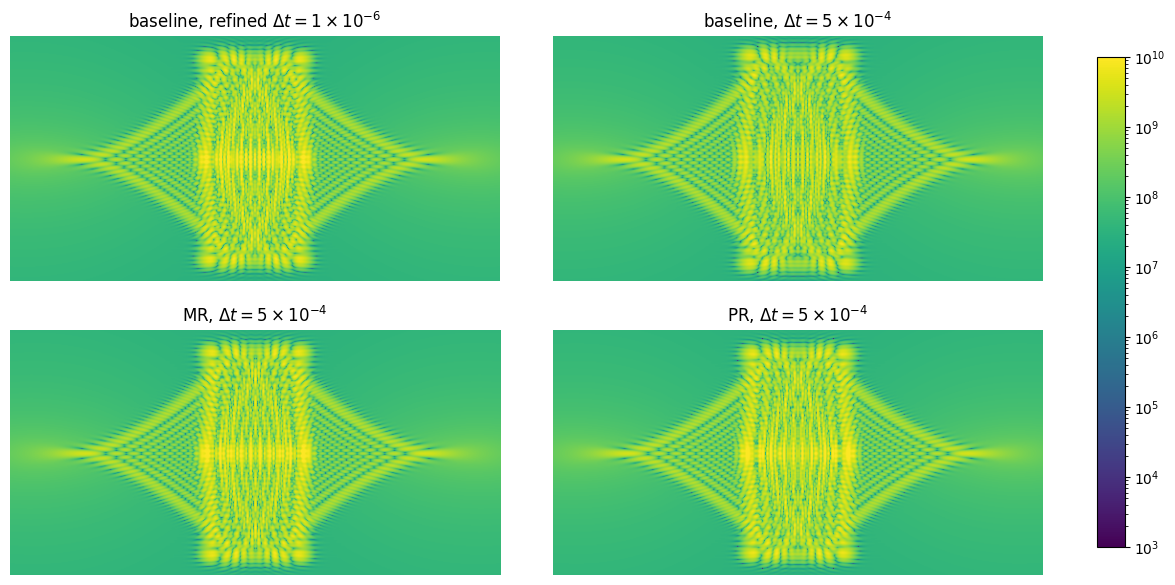

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import matplotlib.colors as colors
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
fold_list = ["./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/","./_data_twoGauss_multiRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/",\
             "./_data_twoGauss_projRlx_E1/imex_ARK3(2)4L[2]SA_2048_0.0005/","./_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_1e-06/"]
#fold_list = ["./_data/imex_ARK3(2)4L[2]SA_1024_1e-05_zero_vel/","./_data/imex_ARK3(2)4L[2]SA_1024_1e-05_zero_vel_relaxed_massOnly/"]
#fold_list = ["./_data/imex_ARK3(2)4L[2]SA_" + str(m) + "_5e-05_zero_vel_relaxedTest/","./_data/imex_ARK3(2)4L[2]SA_" + str(m_r) + "_5e-05_zero_vel_relaxedTest/"]
folder = fold_list[0]
folder_relax = fold_list[1]
folder_proj_relax = fold_list[2]
folder_refined = fold_list[3]
#folder_mass_relax = fold_list[2]
folder_case = folder + "case_dict.pkl"
folder_relax_case = folder_relax + "case_dict.pkl"
folder_proj_relax_case = folder_proj_relax + "case_dict.pkl"
folder_refined_case = folder_refined + "case_dict.pkl"
# folder_mass_relax_case = folder_mass_relax + "case_dict.pkl"
with open(folder_case, 'rb') as file:
    data = pickle.load(file)
    m = data["frame_list"][0].shape
    print(data.keys(),m)
    
with open(folder_relax_case, 'rb') as file:
    data_relax = pickle.load(file)
    m_r = data_relax["frame_list"][0].shape
    print(data_relax.keys(),m_r)

with open(folder_proj_relax_case, 'rb') as file:
    data_proj_relax = pickle.load(file)
    m_pr = data_proj_relax["frame_list"][0].shape
    print(data_proj_relax.keys(),m_pr)

with open(folder_refined_case, 'rb') as file:
    data_refined = pickle.load(file)
    m_ref = data_refined["frame_list"][0].shape
    print(data_refined.keys(),m_ref)

# with open(folder_mass_relax_case, 'rb') as file:
#     data_mass_relax = pickle.load(file)
#     m_mass = data_mass_relax["frame_list"][0].shape
   


i_list = [1.0]#list(range(0,len(data['t_list'])-1))
i_list_relax =[1.0]
i_list_proj_relax =[1.0]#list(range(0,len(data_relax['t_list'])-1))
i_list_refined =[1.0]
t_list = data['t_list']
t_list_relax = data_relax['t_list']
t_list_proj_relax = data_proj_relax['t_list']
t_list_refined = data_refined['t_list']

xlist = data["X"]
x = xlist[0]
y = xlist[1]

xlist = data_relax["X"]
x_r = np.array(xlist[0])
y_r = np.array(xlist[1])

xlist = data_proj_relax["X"]
x_pr = np.array(xlist[0])
y_pr = np.array(xlist[1])

xlist = data_refined["X"]
x_ref = np.array(xlist[0])
y_ref = np.array(xlist[1])  

print([y.min(), y.max(), x.min(), x.max()])
print([y_r.min(), y_r.max(), x_r.min(), x_r.max()])
print([y_pr.min(), y_pr.max(), x_pr.min(), x_pr.max()])
# xlist = data_mass_relax["x"]
# x_r_m = xlist[0]
# y_r_m = xlist[1]

file_n = folder+"frame_"
file_n_relax = folder_relax+"frame_"
file_n_proj_relax = folder_proj_relax+"frame_"
file_n_refined = folder_refined+"frame_"
# file_n_mass_relax = folder_mass_relax+"frame_"



xlim = [3.0/8.0,5.0/8.0]
ylim = [7.0/16.0,9./16.0]
xlim_ind = [int((xlim[0]-x.min())/(x.max()-x.min())*m[0]),int((xlim[1]-x.min())/(x.max()-x.min())*m[0])]
ylim_ind = [int((ylim[0]-y.min())/(y.max()-y.min())*m[1]),int((ylim[1]-y.min())/(y.max()-y.min())*m[1])]
asp = np.diff(ylim)/np.diff(xlim)
print("Ass",asp,xlim_ind,ylim_ind)


fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(2, 2, figure=fig)
#plt.xlim([-xlim,xlim])
#plt.ylim([-xlim,xlim])

print(i_list,i_list_relax,i_list_proj_relax,i_list_refined)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
for i1,i2,i3,i4 in zip(i_list,i_list_relax,i_list_proj_relax,i_list_refined):

   
    
    frame = np.load(file_n + str(i1) + ".npz")['frame']
    print(file_n + str(i1) + ".npz")
    mass = np.mean(np.square(np.abs(frame)))
    
    frame_relax = np.array(np.load(file_n_relax + str(i2) + ".npz")['frame'])
    print(file_n_relax + str(i2) + ".npz")
    mass_relax = np.mean(np.square(np.abs(frame_relax)))

    frame_proj_relax = np.array(np.load(file_n_proj_relax + str(i3) + ".npz")['frame'])
    print("----",frame_proj_relax.dtype)
    print(file_n_proj_relax + str(i3) + ".npz")
    mass_proj_relax = np.mean(np.square(np.abs(frame_proj_relax)))

    frame_refined = np.array(np.load(file_n_refined + str(i4) + ".npz")['frame'])
    print("----",frame_refined.dtype)
    print(file_n_refined + str(i4) + ".npz")
    mass_refined = np.mean(np.square(np.abs(frame_refined)))

    ax = fig.add_subplot(gs[0, 0])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    Z = np.square(np.abs(frame_refined))
    pclm = ax.imshow(Z,extent=[y_ref.min(), y_ref.max(), x_ref.min(), x_ref.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
    #fig.colorbar(pclm,ax=ax)
    ax.axis('off')
    ax.set_title(r"baseline, refined $\Delta t=1\times10^{-6}$")
    ax.set_box_aspect(asp)
    #print(frame.shape,i_list_relax.index(i2),mass,mass_relax)

    #print("Diff",np.max(np.abs(frame-frame_relax)))
    

    ax = fig.add_subplot(gs[0, 1])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    #frame_mass_relax = np.load(file_n_mass_relax + str(i2) + ".npz")['frame']

    Z = np.square(np.abs(frame))
    #pclm = ax.pcolormesh(y,x,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax.imshow(Z,extent=[y.min(), y.max(), x.min(), x.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
    ax.axis('off')
      
    #fig.colorbar(pclm,ax=ax)
    ax.set_title(r"baseline, $\Delta t=5\times10^{-4}$")
    ax.set_box_aspect(asp)
    #fig.colorbar(ax.imshow(np.abs(frame)**2), ax=ax)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.set_box_aspect(asp)
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    Z = np.square(np.abs(frame_relax))
    print("Max difference",np.abs(frame-frame_relax).max())
    ax2.axis('off')
    #pclm = ax2.pcolormesh(y_r,x_r,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax2.imshow(Z,extent=[y_r.min(), y_r.max(), x_r.min(), x_r.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
      
    #fig.colorbar(pclm,ax=ax2)
    ax2.set_title(r"MR, $\Delta t=5\times10^{-4}$")


    ax3 = fig.add_subplot(gs[1, 1])
    ax3.set_box_aspect(asp)
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    Z = np.square(np.abs(frame_proj_relax))
    print("Max difference proj relax",np.abs(frame-frame_proj_relax).max())
    ax3.axis('off')
    #pclm = ax2.pcolormesh(y_r,x_r,Z,norm=LogNorm(vmin=Z.min(), vmax=Z.max()))
    pclm = ax3.imshow(Z,extent=[y_pr.min(), y_pr.max(), x_pr.min(), x_pr.max()] ,norm=colors.LogNorm(vmin=1e3, vmax=1e10))
      
    #fig.colorbar(pclm,ax=ax3)
    ax3.set_title(r"PR, $\Delta t=5\times10^{-4}$")

fig.colorbar(pclm, cax=cbar_ax)
plt.subplots_adjust(wspace=0.0001)


    # ax2 = fig.add_subplot(gs[2, i_list.index(i1)])
    # #ax2.set_xlim([-xlim,xlim])
    # Z = np.abs(np.square(np.abs(frame))-np.square(np.abs(frame_relax)))
    # Z = np.square(np.abs(frame_mass_relax))
    # pclm = ax2.pcolormesh(y_r_m,x_r_m,Z,norm=LogNorm(vmin=Z.min()+1e-14, vmax=Z.max()))
      
    #fig.colorbar(pclm,ax=ax2)
    #ax2.set_title("t = "+str(round(t_list_relax[i+1],2))+", mass = "+str(round(mass_relax,5)))
    #fig.colorbar(ax2.imshow(np.abs(frame_relax)**2), ax=ax2)
    #plt.pause(0.1)
#plt.tight_layout()
plt.savefig("./_figures_two_gauss/two_gauss_density_comparison_2dt0p0005.pdf",dpi=300,bbox_inches='tight')



In [9]:
from os.path import join, isdir
from os import listdir

mypath_multirlax = "./_two_gauss_print/_data_twoGauss_multiRlx_E1_14/"

err_density_max_MR = []
err_density_mean_MR = []
err_mean_MR = []
dir_name_list_MR = [f for f in listdir(mypath_multirlax) if isdir(join(mypath_multirlax, f))]
fold_list_MR = [mypath_multirlax+f+"/" for f in dir_name_list_MR]
dtname_list_MR = [ f.split('_')[-1] for f in dir_name_list_MR ]
dt_list_MR = [float(dt) for dt in dtname_list_MR]
ind = np.argsort(dt_list_MR)
dtname_list_MR = [dtname_list_MR[i] for i in ind]
dt_list_MR = [dt_list_MR[i] for i in ind]
fold_list_MR = [fold_list_MR[i] for i in ind]
last_t_MR = ["1.0000" for _ in range(len(fold_list_MR)+1)]
print("MR dt_list: ",dtname_list_MR)
print("MR dt_list: ",dt_list_MR)

MR dt_list:  ['2e-05', '4e-05', '8e-05', '0.0002', '0.0004', '0.0008', '0.001']
MR dt_list:  [2e-05, 4e-05, 8e-05, 0.0002, 0.0004, 0.0008, 0.001]


dt_list:  [1e-06, 2e-05, 4e-05, 8e-05, 0.0002, 0.0004, 0.0008, 0.001]
MR dt_list:  [2e-05, 4e-05, 8e-05, 0.0002, 0.0004, 0.0008, 0.001]
PR dt_list:  [2e-05, 4e-05, 8e-05, 0.0002, 0.0004, 0.0008, 0.001]
Lengths 8 7 7
Reference  ./_two_gauss_print/_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_1e-06/frame_1.0.npz
Reference mass:  37565252.26621767
./_two_gauss_print/_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_2e-05/ 3.657107747701251e-05 1.0783851002748457 -15.609640474436812
./_two_gauss_print/_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_4e-05/ 0.0002966794919025163 8.70186531015136 -14.609640474436812
./_two_gauss_print/_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_8e-05/ 0.0024672639530366673 71.63561047822886 -13.609640474436812
./_two_gauss_print/_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.0002/ 0.04562865303917154 1252.2270875210697 -12.287712379549449
./_two_gauss_print/_data_twoGauss_E1/imex_ARK3(2)4L[2]SA_2048_0.0004/ 0.2782317661789344 5878.662138147767 -11.287712379549449
./_two_gauss_

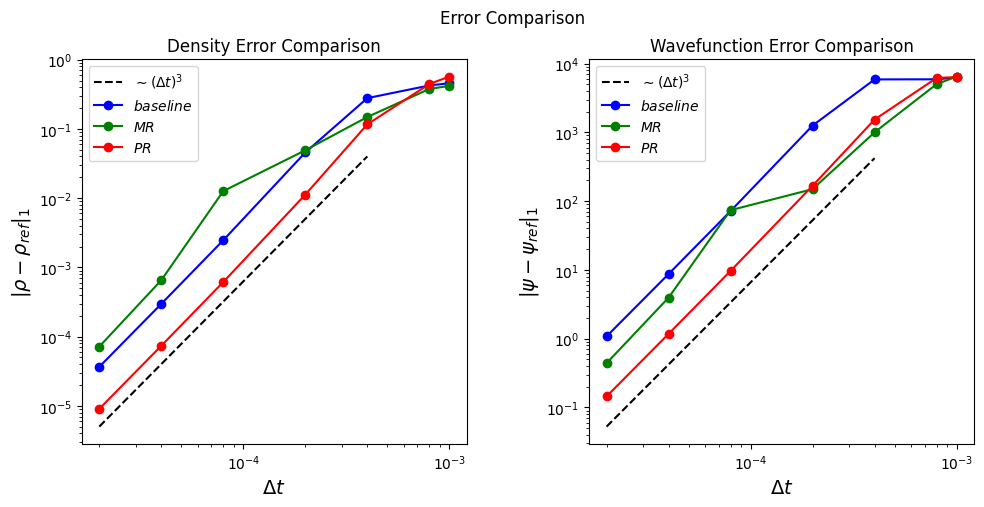

In [10]:


from os.path import join, isdir
from os import listdir
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)
fig.suptitle("Error Comparison")


ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Density Error Comparison")
ax1.set_xlabel("$\Delta t$",fontsize=14)
ax1.set_ylabel(r"$|\rho-\rho_{ref}|_1$",fontsize=14)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Wavefunction Error Comparison")
ax2.set_xlabel("$\Delta t$",fontsize=14)
ax2.set_ylabel(r"$|\psi-\psi_{ref}|_1$",fontsize=14)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xscale('log')
ax2.set_xscale('log')

mypath = "./_two_gauss_print/_data_twoGauss_E1/"
mypath_projrlax = "./_two_gauss_print/_data_twoGauss_projRlx_E1/"
mypath_multirlax = "./_two_gauss_print/_data_twoGauss_multiRlx_E1_14/"






err_density_max = []
err_density_mean = []
err_mean = []
dir_name_list = [f for f in listdir(mypath) if isdir(join(mypath, f))]
fold_list = [mypath+f+"/" for f in dir_name_list]
dtname_list = [ f.split('_')[-1] for f in dir_name_list ]
dt_list = [float(dt) for dt in dtname_list]
ind = np.argsort(dt_list)
dtname_list = [dtname_list[i] for i in ind]
dt_list = [dt_list[i] for i in ind]
fold_list = [fold_list[i] for i in ind]
last_t = ["1.0" for _ in range(len(fold_list)+1)]
# print("dt_list: ",dtname_list)

# print("dir_name_list: ",fold_list)

err_density_max_PR = []
err_density_mean_PR = []
err_mean_PR = []
dir_name_list_PR = [f for f in listdir(mypath_projrlax) if isdir(join(mypath_projrlax, f))]
fold_list_PR = [mypath_projrlax+f+"/" for f in dir_name_list_PR]
dtname_list_PR = [ f.split('_')[-1] for f in dir_name_list_PR ]
dt_list_PR = [float(dt) for dt in dtname_list_PR]
ind = np.argsort(dt_list_PR)
dtname_list_PR = [dtname_list_PR[i] for i in ind]
dt_list_PR = [dt_list_PR[i] for i in ind]
fold_list_PR = [fold_list_PR[i] for i in ind]
last_t_PR = ["1.0" for _ in range(len(fold_list_PR)+1)]

err_density_max_MR = []
err_density_mean_MR = []
err_mean_MR = []
dir_name_list_MR = [f for f in listdir(mypath_multirlax) if isdir(join(mypath_multirlax, f))]
fold_list_MR = [mypath_multirlax+f+"/" for f in dir_name_list_MR]
dtname_list_MR = [ f.split('_')[-1] for f in dir_name_list_MR ]
dt_list_MR = [float(dt) for dt in dtname_list_MR]
ind = np.argsort(dt_list_MR)
dtname_list_MR = [dtname_list_MR[i] for i in ind]
dt_list_MR = [dt_list_MR[i] for i in ind]
fold_list_MR = [fold_list_MR[i] for i in ind]
last_t_MR = ["1.0000" for _ in range(len(fold_list_MR)+1)]





#print("PR dt_list: ",dtname_list_PR)
print("dt_list: ",dt_list)
print("MR dt_list: ",dt_list_MR)
print("PR dt_list: ",dt_list_PR)
print("Lengths",len(dt_list),len(dt_list_MR),len(dt_list_PR))
#print("PR dir_name_list: ",fold_list_PR)
print("Reference ",fold_list[0]+"frame_"+str(last_t[0])+".npz")

ref = np.load(fold_list[0]+"frame_"+str(last_t[0])+".npz")['frame']
ref_density = np.square(np.abs(ref))
ref_mass = ref_density.mean()
print("Reference mass: ",ref_mass)

wgt = ref_density/ref_density.sum()
for i,fold in enumerate(fold_list[1:]):
    
    frame = np.load(fold+"frame_"+last_t[i]+".npz")['frame']
    density = np.square(np.abs(frame))
    #print("mass",np.mean(density),"max density",np.max(density))
    err_density_max.append(np.max(np.abs(density - ref_density)/ref_mass))
    err_density_mean.append( np.mean( np.abs(density - ref_density)/ref_mass) )
    err_mean.append( np.mean( np.abs(frame - ref) ) )
    print(fold,err_density_mean[-1],err_mean[-1],np.log2(dt_list[i+1]))
print(len(dt_list),len(err_density_max))
slp,intersect = np.polyfit(np.log2(dt_list[1:]), np.log2(err_density_mean[:]), 1)
#ax1.plot((dt_list[1:]), (np.power(2,intersect)*(np.array(dt_list[1:])**(slp))), 'b--', label=f"Slope: {slp:.2f}")
slp_sol,intersect_sol = np.polyfit(np.log2(dt_list[1:]), np.log2(err_mean[:]), 1)
#ax2.plot((dt_list[1:]), (np.power(2,intersect_sol)*(np.array(dt_list[1:])**(slp_sol))), 'b--', label=f"Slope: {slp_sol:.2f}")
print("Slope density err (mean): ",slp,slp_sol)


for i,fold in enumerate(fold_list_MR[:]):
    
    frame = np.load(fold+"frame_"+last_t_MR[i]+".npz")['frame']
    density = np.square(np.abs(frame))
    err_density_max_MR.append(np.max(np.abs(density - ref_density)/ref_mass))
    err_density_mean_MR.append( np.mean( np.abs(density - ref_density)/ref_mass) )
    err_mean_MR.append( np.mean( np.abs(frame - ref) ) )
    print(fold,str(last_t_MR[i]),err_density_mean_MR[-1],err_mean_MR[-1])

slp,intersect = np.polyfit(np.log2(dt_list_MR[:]), np.log2(err_density_mean_MR[:]), 1)
slp_sol,intersect_sol = np.polyfit(np.log2(dt_list_MR[:]), np.log2(err_mean_MR[:]), 1)

print("PR Slope density err (mean): ",slp,slp_sol)





for i,fold in enumerate(fold_list_PR[:]):
    
    frame = np.load(fold+"frame_"+last_t_PR[i]+".npz")['frame']
    density = np.square(np.abs(frame))
    err_density_max_PR.append(np.max(np.abs(density - ref_density)/ref_mass))
    err_density_mean_PR.append( np.mean( np.abs(density - ref_density)/ref_mass) )
    err_mean_PR.append( np.mean( np.abs(frame - ref) ) )
    print(fold,str(last_t_PR[i]),err_density_mean_PR[-1],err_mean_PR[-1])

slp,intersect = np.polyfit(np.log2(dt_list_PR[:]), np.log2(err_density_mean_PR[:]), 1)

slp_sol,intersect_sol = np.polyfit(np.log2(dt_list_PR[:]), np.log2(err_mean_PR[:]), 1)

print("PR Slope density err (mean): ",slp,slp_sol)

lind_max = -2
ax1.plot((dt_list_PR[:lind_max]), np.power(2,0.7*intersect_sol)*(np.array(dt_list_PR[:lind_max])**3.0), 'k--', label=r"$\sim(\Delta t)^{3}$")
ax2.plot((dt_list_PR[:lind_max]), np.power(2,1.02*intersect_sol)*(np.array(dt_list_PR[:lind_max])**3.0), 'k--', label=r"$\sim(\Delta t)^{3}$")





print(len(err_density_max),len(err_density_mean))
ax1.plot((dt_list[1:]),(err_density_mean[:]),"o-",color="blue",label=r"$baseline$")
ax1.plot((dt_list_MR[:]),err_density_mean_MR[:],"o-",color="green",label=r"$MR$")
ax1.plot((dt_list_PR[:]),(err_density_mean_PR[:]),"o-",color="red",label=r"$PR$")

ax2.plot((dt_list[1:]),(err_mean[:]),"o-",color="blue",label=r"$baseline$")
ax2.plot((dt_list_MR[:]),err_mean_MR[:],"o-",color="green",label=r"$MR$")
ax2.plot((dt_list_PR[:]),(err_mean_PR[:]),"o-",color="red",label=r"$PR$")


ax1.legend()
ax2.legend()
ax1.set_box_aspect(1.0)
ax2.set_box_aspect(1.0)

plt.savefig("./_figures_two_gauss/two_gauss_error_conv_2048.pdf",dpi=300,bbox_inches='tight')